# Botsingsmodel

We waren gebleven bij het maken van een botsingsmodel, waarbij we nu twee deeltjes hebben die onderhevig zijn aan zwaartekracht. 

Laten we de zwaartekracht even vergeten en alleen 1D kijken.

```{exercise}
1. Gegeven twee particles elk met straal $R$ en posities $r_1$ en $r_2$. Wat is de (wiskundige) voorwaarde voor een botsing?

2. Zoek op wat de numpy functie np.linalg.norm doet en bedenk hoe die gebruikt kan worden voor het detecteren van een botsing.

3. Vul onderstaande code aan waarbij de twee deeltjes van richting veranderen wanneer ze botsen.

4. Automatiseer en maak de code eleganter waar mogelijk. Kijk daarvoor ook terug naar het aanmaken van een particlearray.
```


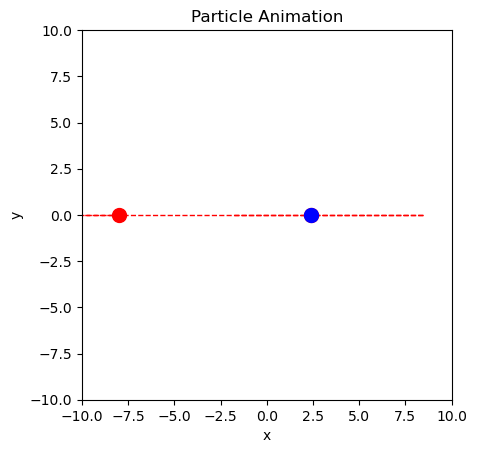

In [ ]:
# Importeren van libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Define a class for a particle
class ParticleClass:
    def __init__(self, m, v, r, R):
        self.m = m                  # mass of the particle
        self.v = np.array(v, dtype=float)  # velocity vector
        self.r = np.array(r, dtype=float)  # position vector
        self.R = np.array(R, dtype=float)  # radius of the particle

    def update_position(self, dt):
        self.r += self.v * dt 

    def collide_detection(self, other):
        return .....

# Simulation parameters
dt = 0.1         # time step
num_steps = 200  # number of time steps

particleA = ParticleClass(m=1.0, v=[2.5, 0], r=[-2.0, 0.0],R=0.45)  
particleB = ParticleClass(m=1.0, v=[-1, 0], r=[0.0, 0.0],R=0.45)  

track_x = []
track_y = []


# Create the figure and axis

fig, ax = plt.subplots()

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
track_line, = ax.plot([], [], 'r--', linewidth=1)  

# Toon het deeltje als een rode stip
dot, = ax.plot([], [], 'ro', markersize=10); # semicolon to suppress output
dotA, = ax.plot([], [], 'ro', markersize=10)
dotB, = ax.plot([], [], 'bo', markersize=10)


# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    particleA.update_position(dt)
    particleB.update_position(dt)

    track_x.append(particleA.r[0])
    track_y.append(particleA.r[1])
    track_line.set_data(track_x, track_y)
    
    dotA.set_data([particleA.r[0]], [particleA.r[1]])
    dotB.set_data([particleB.r[0]], [particleB.r[1]])

    #collision detection and response
    if particleA.collide_detection(particleB):
        ......
        ......

    # wall collision detection and response
    if particleA.r[0]**2>100: 
        particleA.v[0] = -particleA.v[0]
    if particleA.r[1]**2>100: 
        particleA.v[1] = -particleA.v[1]

    dot.set_data([particleB.r[0]], [particleB.r[1]])
    if particleB.r[0]**2>100: 
        particleB.v[0] = -particleB.v[0]
    if particleB.r[1]**2>100: 
        particleB.v[1] = -particleB.v[1]

    return dot, track_line

# Create animation
ani = FuncAnimation(fig, update, frames=range(num_steps), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())


In [7]:
### BEGIN SOLUTION
# Importeren van libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Define a class for a particle
class ParticleClass:
    def __init__(self, m, v, r, R):
        self.m = m                  # mass of the particle
        self.v = np.array(v, dtype=float)  # velocity vector
        self.r = np.array(r, dtype=float)  # position vector
        self.R = np.array(R, dtype=float)  # radius of the particle

    def update_position(self, dt):
        self.r += self.v * dt 

    def collide_detection(self, other):
        return np.linalg.norm(self.r - other.r) < (self.R + other.R)

# Simulation parameters
dt = 0.1         # time step
num_steps = 200  # number of time steps
boxsize = 10


particle_array = []

for i in range(1):
    particle_array.append(ParticleClass(m=1.0, v=[np.random.uniform(-5,5), 0], r=[0.0, 0.0],R=1.0))
    particle_array[i].update_position(1.0)

particle_array[0] = ParticleClass(m=1.0, v=[2.5, 0], r=[-2.0, 0.0],R=0.45)  
particle_array[1] = ParticleClass(m=1.0, v=[-1, 0], r=[0.0, 0.0],R=0.45)  


track_x = []
track_y = []


# Create the figure and axis

fig, ax = plt.subplots()

ax.set_xlim(-boxsize, boxsize)
ax.set_ylim(-boxsize, boxsize)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")
track_line, = ax.plot([], [], 'r--', linewidth=1)  

# Toon het deeltje als een rode stip
dot, = ax.plot([], [], 'ro', markersize=10); # semicolon to suppress output

# Create the particle as a red dot
dotA, = ax.plot([], [], 'ro', markersize=10)
dotB, = ax.plot([], [], 'bo', markersize=10)



# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    particleA.update_position(dt)
    particleB.update_position(dt)

    track_x.append(particleA.r[0])
    track_y.append(particleA.r[1])
    track_line.set_data(track_x, track_y)
    
    dotA.set_data([particleA.r[0]], [particleA.r[1]])
    dotB.set_data([particleB.r[0]], [particleB.r[1]])

    #collision detection and response
    if particleA.collide_detection(particleB):
        particleA.v[0] = -particleA.v[0]
        particleB.v[0] = -particleB.v[0]

    # wall collision detection and response
    if particleA.r[0]**2>boxsize**2: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleA.v[0] = -particleA.v[0]
    if particleA.r[1]**2>boxsize**2: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleA.v[1] = -particleA.v[1]

    dot.set_data([particleB.r[0]], [particleB.r[1]])
    if particleB.r[0]**2>boxsize**2: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleB.v[0] = -particleB.v[0]
    if particleB.r[1]**2>boxsize**2: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleB.v[1] = -particleB.v[1]

    return dot, track_line

# Create animation
ani = FuncAnimation(fig, update, frames=range(num_steps), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())
### END_SOLUTION

IndexError: list assignment index out of range

now with collission formula
know.. in updating, vb relies on va, so use hulpvariabele

In [ ]:
### BEGIN_SOLUTION
# Define a class for a particle
class ParticleClass:
    def __init__(self, m, v, r, R):
        self.m = m                  # mass of the particle
        self.v = np.array(v, dtype=float)  # velocity vector
        self.r = np.array(r, dtype=float)  # position vector
        self.R = np.array(R, dtype=float)  # radius of the particle

    def update_position(self, dt):
        """Update the particle's position based on its velocity and time step dt."""
        self.r += self.v * dt 

    def collide_detection(self, other):
        """Check for collision with another particle."""
        return np.linalg.norm(self.r - other.r) <= (self.R + other.R)

# Simulation parameters
dt = 0.1         # time step
num_steps = 530  # number of time steps

particleA = ParticleClass(m=1.0, v=[0, 0], r=[-2.0, 0.0],R=0.45)  
particleB = ParticleClass(m=100.0, v=[-1, 0], r=[2.0, 0.0],R=0.45)  

# Create the figure and axis

fig, ax = plt.subplots()

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")

counter = 0

# Create the particle as a red dot
dotA, = ax.plot([], [], 'ro', markersize=10)
dotB, = ax.plot([], [], 'bo', markersize=10)

counter_text = ax.text(-9.5, 9, "")

# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    global counter
    particleA.update_position(dt)
    particleB.update_position(dt)

    track_x.append(particleA.r[0])
    track_y.append(particleA.r[1])
    track_line.set_data(track_x, track_y)
    
    dotA.set_data([particleA.r[0]], [particleA.r[1]])
    dotB.set_data([particleB.r[0]], [particleB.r[1]])

    counter_text.set_text(f"Collisions: {counter}")

    #collision detection and response
    if particleA.collide_detection(particleB):
        counter += 1
        vA, vB, mA, mB, rA, rB = particleA.v, particleB.v, particleA.m, particleB.m, particleA.r, particleB.r
        vA_new = vA - 2 * mB / (mA + mB) * np.dot(vA - vB, rA - rB) / (1e-12+np.linalg.norm(rA - rB))**2 * (rA - rB)
        vB_new = vB - 2 * mA / (mA + mB) * np.dot(vB - vA, rB - rA) / (1e-12+np.linalg.norm(rB - rA))**2 * (rB - rA)
        particleA.v = vA_new
        particleB.v = vB_new


    # wall collision detection and response
    if particleA.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        counter += 1
        particleA.v[0] = -particleA.v[0]
    if particleA.r[1]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleA.v[1] = -particleA.v[1]

    dot.set_data([particleB.r[0]], [particleB.r[1]])
    if particleB.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleB.v[0] = -particleB.v[0]
    if particleB.r[1]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleB.v[1] = -particleB.v[1]

    return dot, track_line, counter_text

# Create animation
ani = FuncAnimation(fig, update, frames=range(200), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())
### END_SOLUTION


Nu met g en als superball

In [ ]:
### BEGIN_SOLUTION
# Define a class for a particle

g = np.array([0.0, -5.0])  

class ParticleClass:
    def __init__(self, m, v, r, R):
        self.m = m                  # mass of the particle
        self.v = np.array(v, dtype=float)  # velocity vector
        self.r = np.array(r, dtype=float)  # position vector
        self.R = np.array(R, dtype=float)  # radius of the particle

    def update_position(self, dt):
        """Update the particle's position based on its velocity and time step dt."""
        self.r += self.v * dt + 1/2 * a * dt**2 
    
    def update_velocity(self, dt):
        self.v += g*dt

    def collide_detection(self, other):
        """Check for collision with another particle."""
        return np.linalg.norm(self.r - other.r) <= (self.R + other.R)

# Simulation parameters
dt = 0.1         # time step
num_steps = 530  # number of time steps

particleA = ParticleClass(m=1.0, v=[0, 0], r=[0.0, 3*.45],R=0.45)  
particleB = ParticleClass(m=2.0, v=[0, 0], r=[0.0, 0.0],R=0.45)  

# Create the figure and axis

fig, ax = plt.subplots()

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
ax.set_title("Particle Animation")
ax.set_xlabel("x")
ax.set_ylabel("y")

counter = 0

# Create the particle as a red dot
dotA, = ax.plot([], [], 'ro', markersize=10)
dotB, = ax.plot([], [], 'bo', markersize=10)

counter_text = ax.text(-9.5, 9, "")

# Initialization function for animation
def init():
    dot.set_data([], [])
    return dot,

# Update function for each frame
def update(frame):
    global counter
    particleA.update_position(dt)
    particleB.update_position(dt)

    particleA.update_velocity(dt)
    particleB.update_velocity(dt)
    
    track_x.append(particleA.r[0])
    track_y.append(particleA.r[1])
    track_line.set_data(track_x, track_y)
    
    dotA.set_data([particleA.r[0]], [particleA.r[1]])
    dotB.set_data([particleB.r[0]], [particleB.r[1]])

    counter_text.set_text(f"Collisions: {counter}")

    #collision detection and response
    if particleA.collide_detection(particleB):
        counter += 1
        vA, vB, mA, mB, rA, rB = particleA.v, particleB.v, particleA.m, particleB.m, particleA.r, particleB.r
        vA_new = vA - 2 * mB / (mA + mB) * np.dot(vA - vB, rA - rB) / (1e-12+np.linalg.norm(rA - rB))**2 * (rA - rB)
        vB_new = vB - 2 * mA / (mA + mB) * np.dot(vB - vA, rB - rA) / (1e-12+np.linalg.norm(rB - rA))**2 * (rB - rA)
        particleA.v = vA_new
        particleB.v = vB_new


    # wall collision detection and response
    if particleA.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        counter += 1
        particleA.v[0] = -particleA.v[0]
    if particleA.r[1]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleA.v[1] = -particleA.v[1]

    dot.set_data([particleB.r[0]], [particleB.r[1]])
    if particleB.r[0]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleB.v[0] = -particleB.v[0]
    if particleB.r[1]**2>100: # Check if particle is outside the bounds, np.abs could be used but is slower
        particleB.v[1] = -particleB.v[1]

    return dot, track_line, counter_text

# Create animation
ani = FuncAnimation(fig, update, frames=range(200), init_func=init, blit=True, interval=50)

# For Jupyter notebook:
from IPython.display import HTML
HTML(ani.to_jshtml())
### END_SOLUTION
